# Supervised Learning Methods

In [19]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#dataset
from sklearn.datasets import load_breast_cancer

#for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Task 1: Data Loading & Exploration ()

In [20]:
#display options
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', context='notebook')

#load the dataset
data = load_breast_cancer()

#build the df and separate the target
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

#transform the target into 0-1 instead of malignant-benign
class_names = dict(enumerate(data.target_names))
print('Class label mapping:', class_names)

Class label mapping: {0: np.str_('malignant'), 1: np.str_('benign')}


In [21]:
#shape and NA
print(f'Feature matrix X shape: {X.shape}')
print(f'Target vector y shape:  {y.shape}')
print('Data types of features:')
print(X.dtypes.value_counts())
print("\n")
print('Missing values in X?', X.isna().any().any())
print('Missing values in y?', y.isna().any())
print("\n")
X.head()

Feature matrix X shape: (569, 30)
Target vector y shape:  (569,)
Data types of features:
float64    30
Name: count, dtype: int64


Missing values in X? False
Missing values in y? False




,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


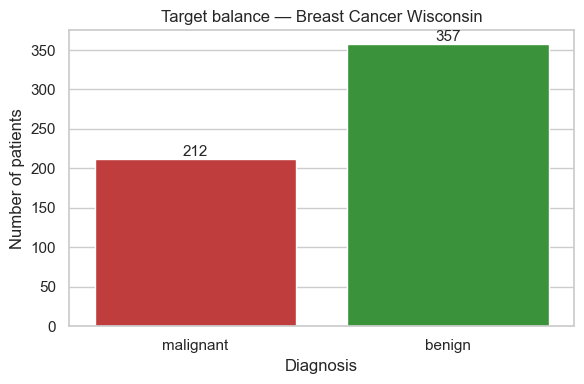

In [22]:
#target balance
counts = y.value_counts().sort_index()
proportions = y.value_counts(normalize=True).sort_index()

balance = pd.DataFrame({
    'count': counts,
    'proportion': proportions.round(3)
})
balance.index = [class_names[i] for i in balance.index]
balance

# Bar plot of target counts
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=y.map(class_names), order=['malignant', 'benign'],
              hue=y.map(class_names),
              palette={'malignant': '#d62728', 'benign': '#2ca02c'},
              legend=False, ax=ax)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
ax.set_title('Target balance — Breast Cancer Wisconsin')
ax.set_xlabel('Diagnosis')
ax.set_ylabel('Number of patients')
plt.tight_layout()
plt.show()

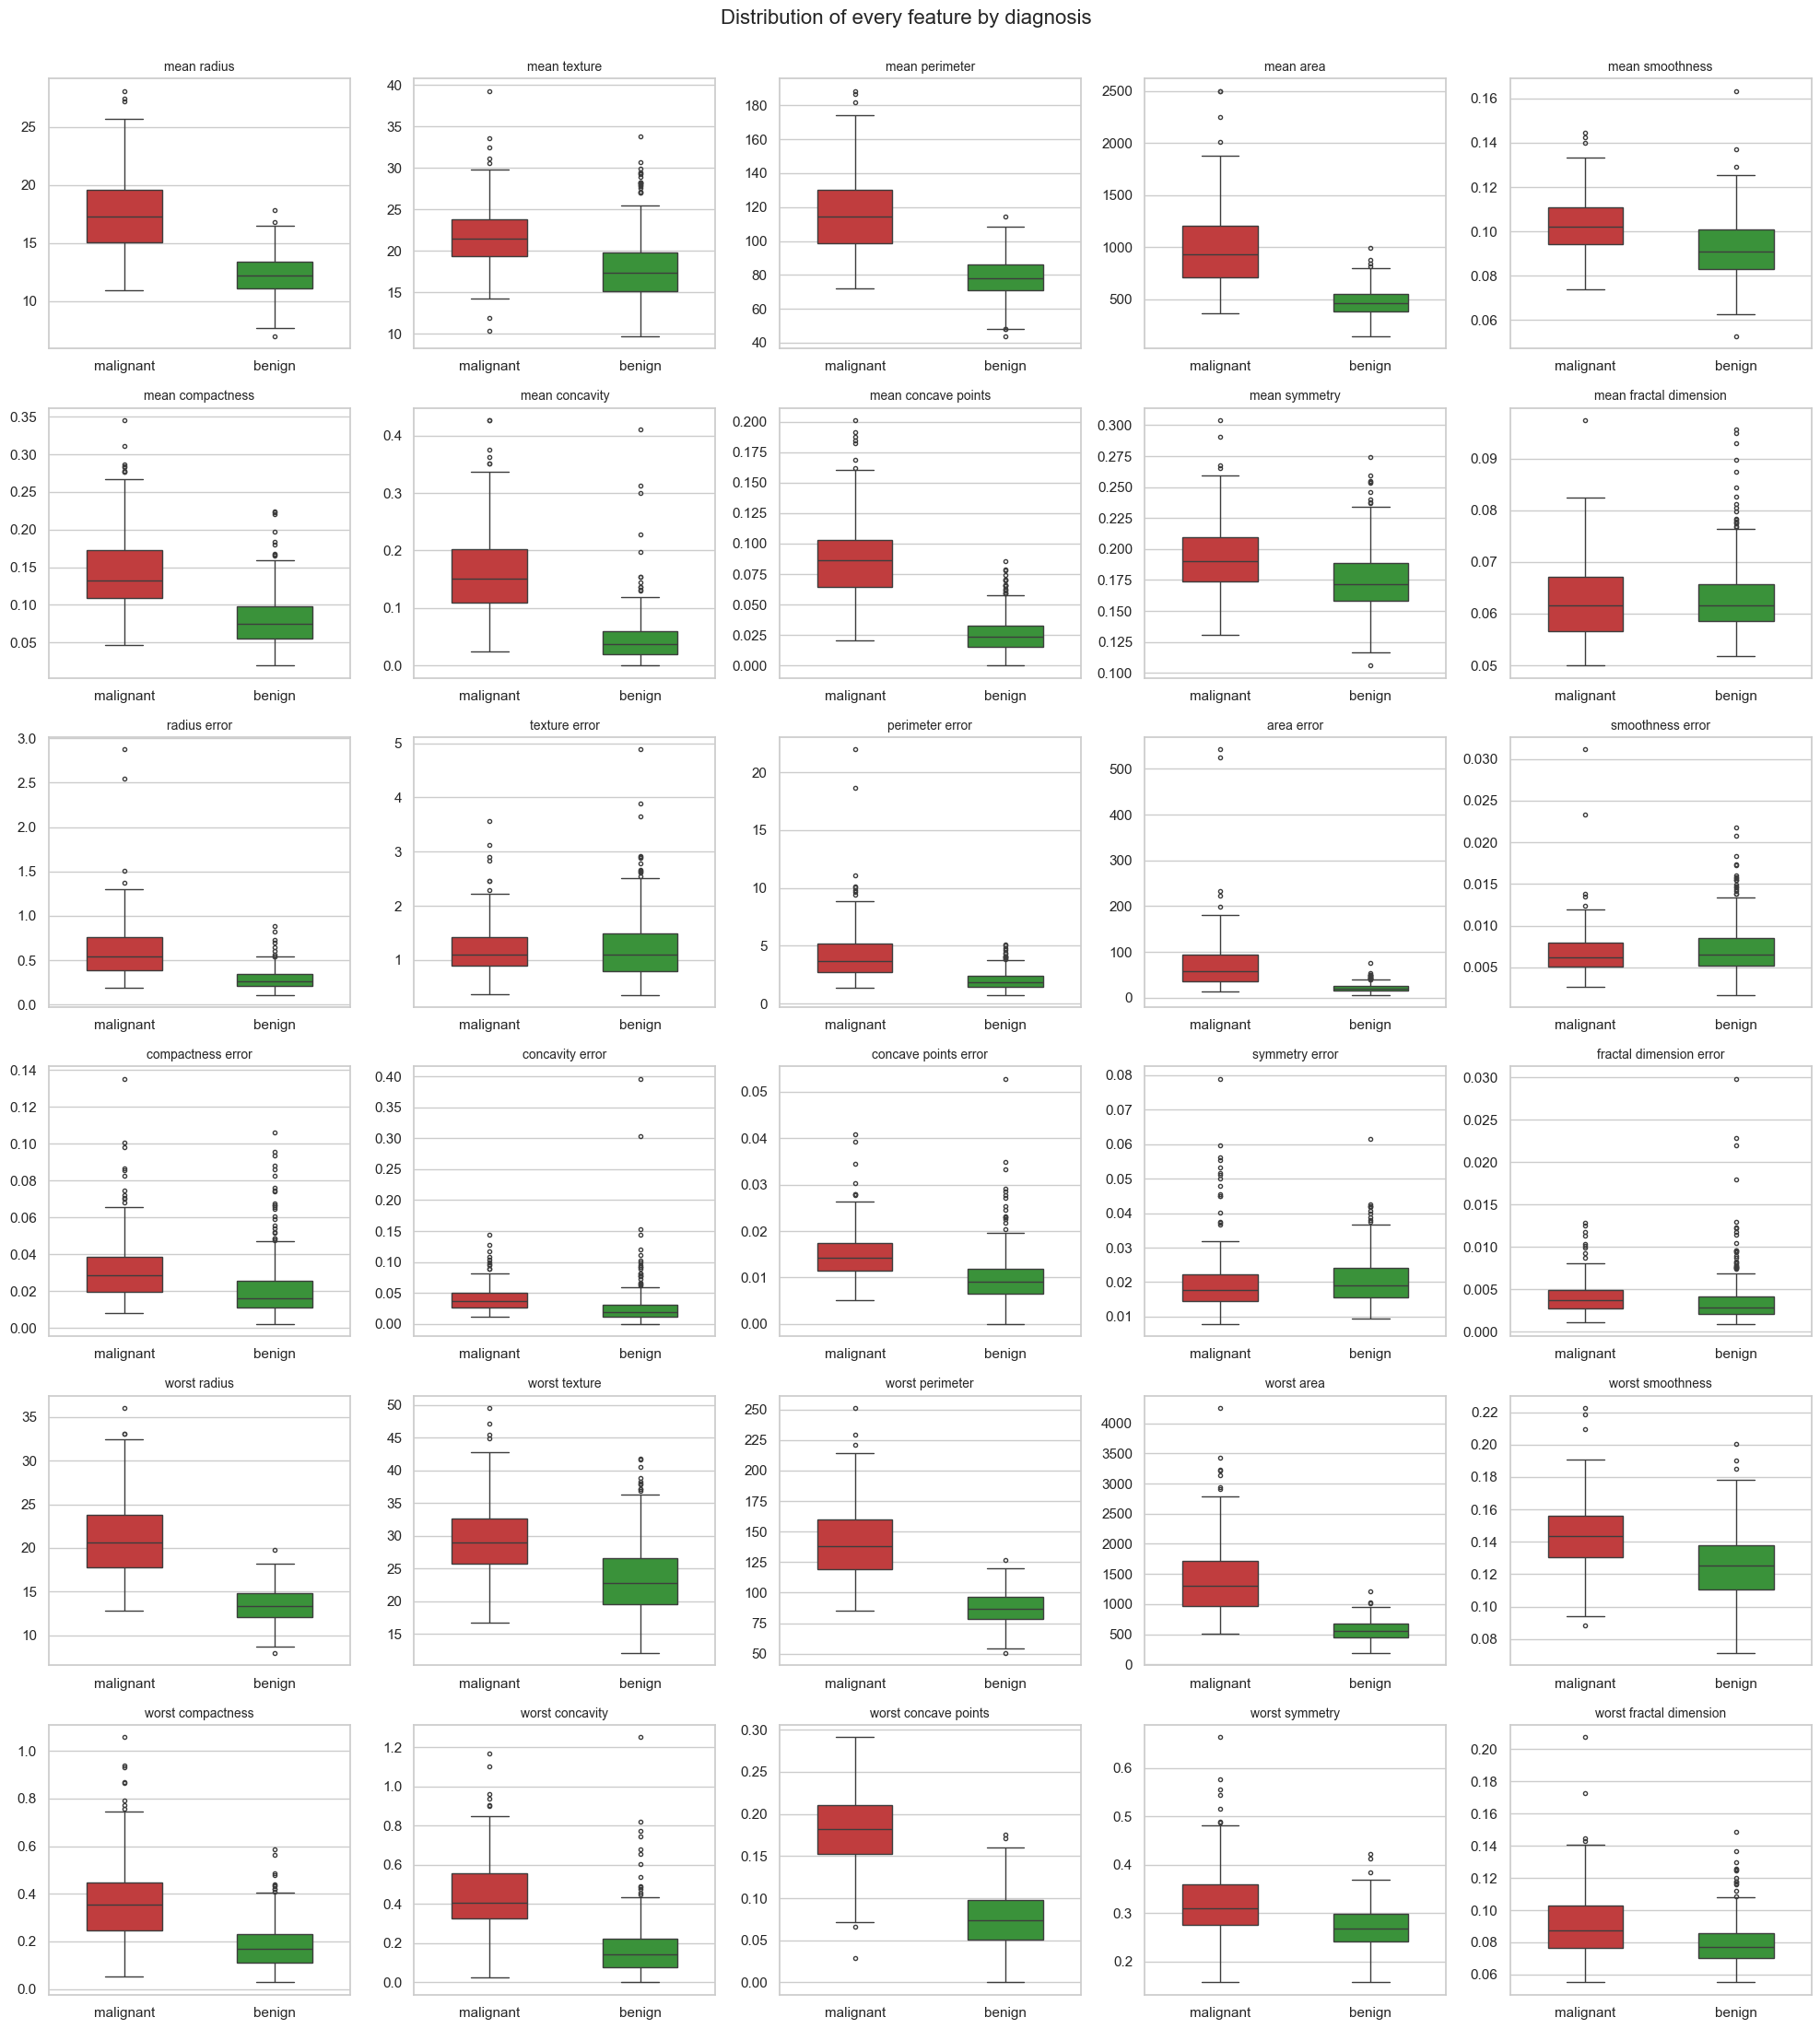

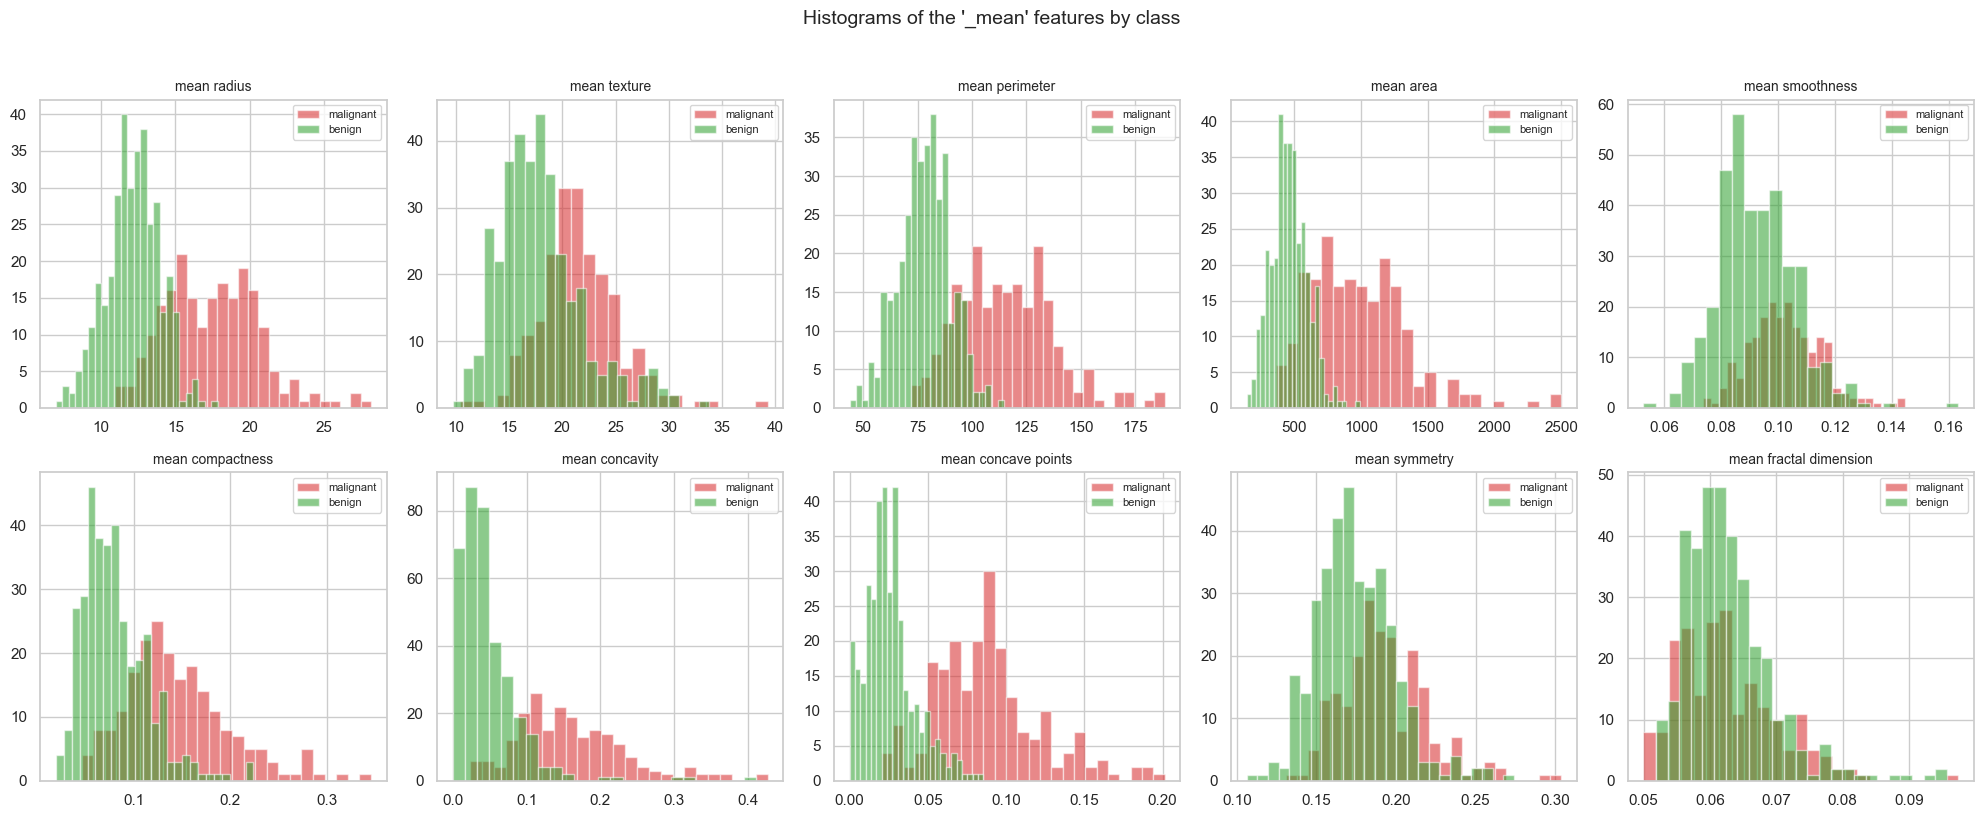

In [23]:
#summary statistics
X.describe().T

#we add a colum with the target for looking what feature separates better the target classes
df_long = X.copy()
df_long['diagnosis'] = y.map(class_names)

feature_groups = ['mean', 'error', 'worst']
fig, axes = plt.subplots(6, 5, figsize=(20, 22))
axes = axes.flatten()

palette = {'malignant': '#d62728', 'benign': '#2ca02c'}

for i, feat in enumerate(X.columns):
    sns.boxplot(data=df_long, x='diagnosis', y=feat,
            order=['malignant', 'benign'],
            hue='diagnosis', palette=palette, legend=False,
            ax=axes[i], width=0.5, fliersize=3)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.suptitle('Distribution of every feature by diagnosis', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

#histograms for the 'mean' feature group
mean_features = [c for c in X.columns if c.startswith('mean')]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, feat in enumerate(mean_features):
    for cls_id, cls_name in class_names.items():
        axes[i].hist(X.loc[y == cls_id, feat], bins=25, alpha=0.55,
                     label=cls_name, color=palette[cls_name])
    axes[i].set_title(feat, fontsize=10)
    axes[i].legend(fontsize=8)
plt.suptitle("Histograms of the '_mean' features by class", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

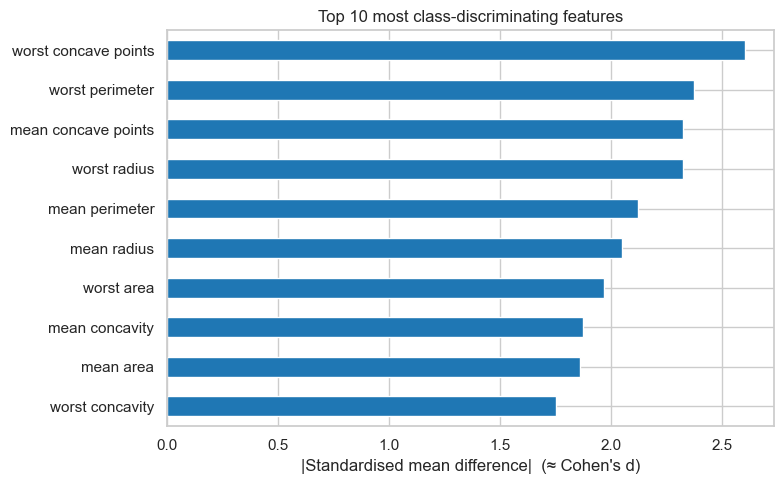

Top 10 features by separating power:
worst concave points    2.60
worst perimeter         2.37
mean concave points     2.33
worst radius            2.32
mean perimeter          2.12
mean radius             2.05
worst area              1.97
mean concavity          1.87
mean area               1.86
worst concavity         1.75


In [24]:
#we look (objectibly) what variables distinguish better both classes (malignant-benign)
def standardised_mean_diff(x, group): #cohen's d
    g0 = x[group == 0]
    g1 = x[group == 1]
    pooled_std = np.sqrt((g0.var(ddof=1) + g1.var(ddof=1)) / 2)
    if pooled_std == 0:
        return 0.0
    return (g0.mean() - g1.mean()) / pooled_std

smd = X.apply(lambda col: standardised_mean_diff(col, y)) #apply for every colum
smd_sorted = smd.abs().sort_values(ascending=False)

top10 = smd_sorted.head(10)
fig, ax = plt.subplots(figsize=(8, 5))
top10.iloc[::-1].plot(kind='barh', color='#1f77b4', ax=ax)
ax.set_xlabel("|Standardised mean difference|  (≈ Cohen's d)")
ax.set_title('Top 10 most class-discriminating features')
plt.tight_layout()
plt.show()

print('Top 10 features by separating power:')
print(top10.round(2).to_string())

We can see that all this variables have a smd > 1.5, which means that the variable itself is good separating the clases.

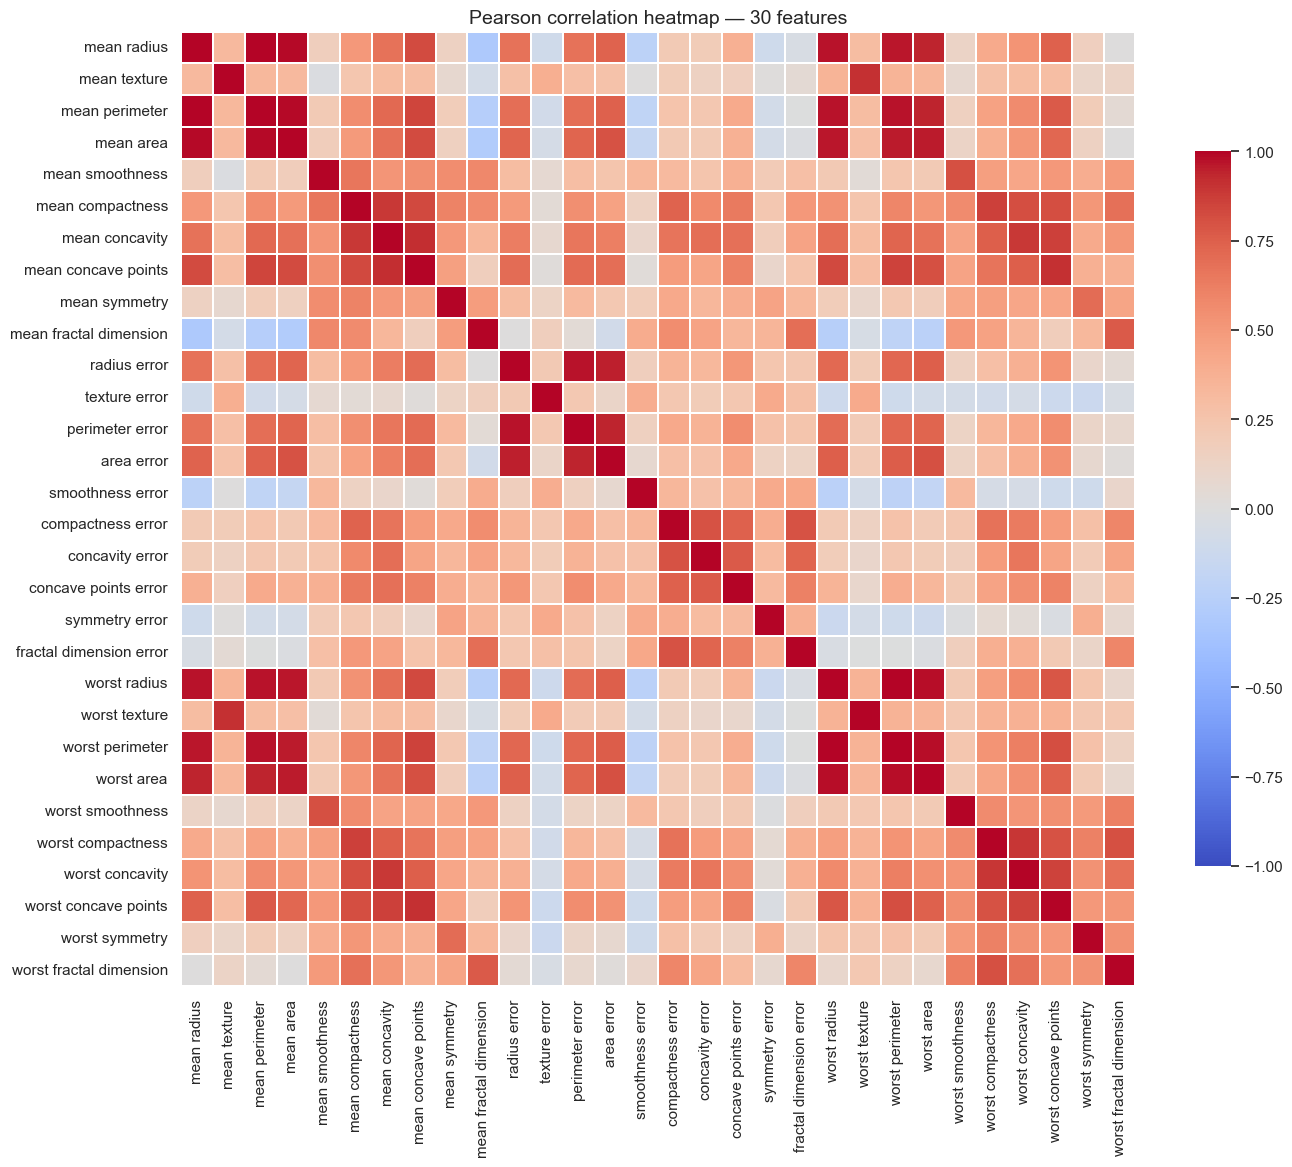

,feature_1,feature_2,corr,abs_corr
0,mean radius,mean perimeter,0.998,0.998
1,worst radius,worst perimeter,0.994,0.994
2,mean radius,mean area,0.987,0.987
3,mean perimeter,mean area,0.987,0.987
4,worst radius,worst area,0.984,0.984
5,worst perimeter,worst area,0.978,0.978
6,radius error,perimeter error,0.973,0.973
7,mean perimeter,worst perimeter,0.970,0.970
8,mean radius,worst radius,0.970,0.970
9,mean perimeter,worst radius,0.969,0.969


In [25]:
#correlations

corr = X.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Pearson correlation heatmap — 30 features', fontsize=14)
plt.tight_layout()
plt.show()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
pairs = (
    corr.where(mask)
        .stack()
        .rename('corr')
        .reset_index()
        .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2'})
)
#rank pair with most correlation
pairs['abs_corr'] = pairs['corr'].abs()
top_pairs = pairs.sort_values('abs_corr', ascending=False).head(15).reset_index(drop=True)
top_pairs.round(3)

# Task 2: Preprocessing & Feature Analysis ()

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# split the data into training (80%) and test (20%) sets. 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

# training based normalisation for the models sensitive to feature scale
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to df 
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

print("Training samples: ", X_train.shape[0])
print("Test samples:     ", X_test.shape[0])

# check target is splitted evenly in train and test dataset
print("Target proportion in train dataset:\n", pd.Series(y_train).value_counts(normalize=True))
print("Target proportion in test dataset:\n", pd.Series(y_test).value_counts(normalize=True))

Training samples:  455
Test samples:      114
Target proportion in train dataset:
 target
1    0.626374
0    0.373626
Name: proportion, dtype: float64
Target proportion in test dataset:
 target
1    0.631579
0    0.368421
Name: proportion, dtype: float64


## Task 3 — K-Nearest Neighbours (KNN)

This section evaluates K-Nearest Neighbours classifiers for \(k = 1\) to \(k = 20\). For each value of \(k\), the model is trained on the scaled training data and evaluated on the scaled test data using accuracy.

KNN is distance-based, so feature scaling is essential. The scaled datasets created in Task 2 are used here to ensure that features with larger numerical ranges do not dominate the distance calculation.

In [27]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
import time

### 3.1 Hyperparameter sweep for \(k\)

The number of neighbours, \(k\), controls the flexibility of the KNN model. The following loop trains one KNN classifier for each value of \(k\) from 1 to 20 and records the corresponding test accuracy.

In [28]:
# Define the range of k values required by the assignment
k_values = range(1, 21)

# Store test accuracy for each k
knn_accuracies = []

# Train and evaluate one KNN model for each k value
for k in k_values:
    # Create KNN classifier with the current number of neighbours
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # Fit the model using the scaled training data
    knn.fit(X_train_scaled, y_train)
    
    # Predict labels for the scaled test data
    y_pred = knn.predict(X_test_scaled)
    
    # Calculate test accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    # Save the accuracy for later comparison
    knn_accuracies.append(accuracy)

# Store the results in a DataFrame for clear display
knn_results = pd.DataFrame({
    "k": list(k_values),
    "test_accuracy": knn_accuracies
})

knn_results

,k,test_accuracy
0,1,0.938596
1,2,0.929825
2,3,0.982456
3,4,0.947368
4,5,0.956140
5,6,0.956140
6,7,0.973684
7,8,0.973684
8,9,0.973684
9,10,0.964912


### 3.2 Accuracy curve

The accuracy values are plotted against \(k\) to visually compare model performance and identify the best-performing number of neighbours.

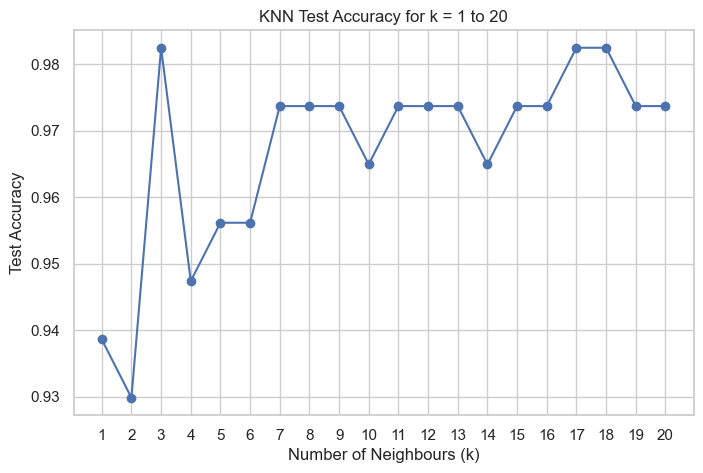

In [29]:
# Create the accuracy vs k plot
plt.figure(figsize=(8, 5))

plt.plot(
    knn_results["k"],
    knn_results["test_accuracy"],
    marker="o"
)

# Show every k value from 1 to 20 on the x-axis
plt.xticks(range(1, 21))

# Add clear axis labels and title
plt.xlabel("Number of Neighbours (k)")
plt.ylabel("Test Accuracy")
plt.title("KNN Test Accuracy for k = 1 to 20")

# Add grid for readability
plt.grid(True)

plt.show()

### 3.3 Selecting the optimal \(k\)

The optimal value of \(k\) is selected as the value with the highest test accuracy. If multiple values achieve the same maximum accuracy, the first occurrence is selected by `idxmax()`.

In [30]:
# Find the row index with the highest test accuracy
best_index = knn_results["test_accuracy"].idxmax()

# Extract the corresponding k value and accuracy
best_k = int(knn_results.loc[best_index, "k"])
best_knn_accuracy = knn_results.loc[best_index, "test_accuracy"]

print(f"Best k: {best_k}")
print(f"Best test accuracy: {best_knn_accuracy:.4f}")

Best k: 3
Best test accuracy: 0.9825


The best value of \(k\) was selected based on the highest test accuracy across the tested range from 1 to 20. In this run, the selected value was \(k = 3\), with a test accuracy of approximately 98.25%.

Smaller values of \(k\), especially \(k = 1\), create a more flexible model that can capture very local patterns in the training data. However, this may increase variance and lead to overfitting because predictions depend strongly on individual nearby points.

Larger values of \(k\) produce a smoother decision boundary by averaging over more neighbours. This can reduce variance, but if \(k\) becomes too large, the model may underfit by ignoring useful local structure.

Therefore, \(k = 3\) was selected as the final KNN setting because it achieved the highest observed test accuracy while still keeping the model relatively simple.

### 3.4 Final KNN model

The final KNN classifier is trained using the selected value of \(k\). The training time is recorded so that KNN can later be compared with the other supervised learning models in Task 7.

In [31]:
# Start timer to measure training time
start_time = time.time()

# Train final KNN model using the selected k
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

# Stop timer after model fitting
knn_train_time = time.time() - start_time

# Predict class labels on the scaled test set
y_pred_knn = final_knn.predict(X_test_scaled)

# Predict class probabilities for ROC/AUC calculation
# Column 1 corresponds to the positive class: benign
y_proba_knn = final_knn.predict_proba(X_test_scaled)[:, 1]

### 3.5 Classification report

The classification report shows precision, recall, and F1-score for both malignant and benign cases, as well as overall accuracy.

In [32]:
# Print precision, recall, F1-score, and support for each class
print("Classification Report for Final KNN Model")
print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=["malignant", "benign"]
    )
)

Classification Report for Final KNN Model
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        42
      benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



### 3.6 Confusion matrix

The confusion matrix shows the number of correct and incorrect predictions for each class. This is especially useful in a medical setting because false negatives for malignant cases are clinically important.

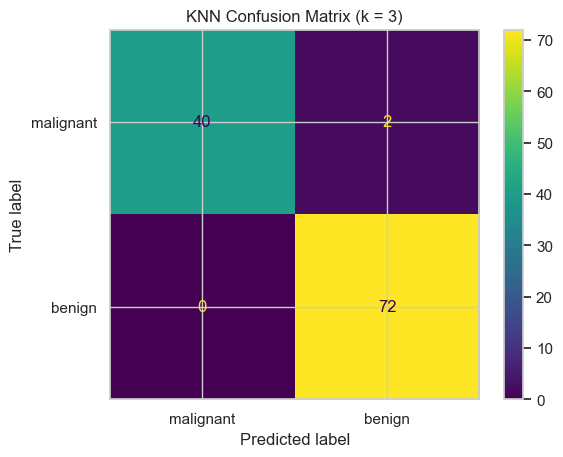

In [33]:
# Compute confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Display confusion matrix with class labels
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=["malignant", "benign"]
)

disp.plot()
plt.title(f"KNN Confusion Matrix (k = {best_k})")
plt.show()

### 3.7 Saving KNN results for model comparison

The key KNN evaluation metrics are saved in the shared `results` dictionary. These values will be reused later for the global model comparison, summary table, and ROC curve in Task 7.

In [34]:
# Calculate final evaluation metrics
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_f1_macro = f1_score(y_test, y_pred_knn, average="macro")

# Calculate ROC curve and AUC
knn_fpr, knn_tpr, _ = roc_curve(y_test, y_proba_knn)
knn_auc = auc(knn_fpr, knn_tpr)

# Create results dictionary if it does not already exist
if "results" not in globals():
    results = {}

# Store KNN metrics for later comparison with other models
results["KNN"] = {
    "accuracy": knn_accuracy,
    "f1_macro": knn_f1_macro,
    "auc": knn_auc,
    "train_time": knn_train_time,
    "fpr": knn_fpr,
    "tpr": knn_tpr
}

results["KNN"]

{'accuracy': 0.9824561403508771,
 'f1_macro': 0.9809555629802873,
 'auc': 0.9834656084656085,
 'train_time': 0.0012364387512207031,
 'fpr': array([0.        , 0.02380952, 0.04761905, 0.0952381 , 1.        ]),
 'tpr': array([0.        , 0.80555556, 1.        , 1.        , 1.        ])}

The final KNN model achieved strong performance, with high accuracy, macro F1-score, and ROC AUC. The confusion matrix shows that most test observations were correctly classified.

In a clinical classification problem, false negatives are particularly important because they represent malignant tumours incorrectly predicted as benign. In this result, the malignant recall should therefore be interpreted carefully alongside the overall accuracy.

The KNN results have also been saved in the shared `results` dictionary so they can be included in the final model comparison in Task 7.

# Task 4: Logistic Regression ()

This section evaluates a Logistic Regression classifier using different values of the regularization hyperparameter ( C ). For each value of ( C ), the model is trained on the scaled training data and evaluated on the scaled test data using metrics such as accuracy and ROC-AUC.

Logistic Regression is sensitive to feature magnitudes due to the regularization term, making feature scaling important. Therefore, the scaled datasets created in Task 2 are used to ensure that all features contribute equally to the model training process.

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report, confusion_matrix, f1_score
import time
from sklearn.metrics import ConfusionMatrixDisplay

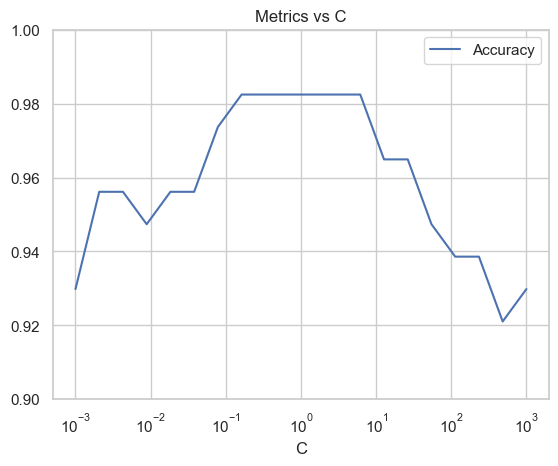

Best C by Accuracy: 0.1624 with Accuracy: 0.9825


In [36]:
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

C_values = np.logspace(-3, 3, 20)

accs = []

for C in C_values:
    lr = LogisticRegression(C=C, max_iter=1000)
    lr.fit(X_train_scaled_df, y_train)
    
    y_pred = lr.predict(X_test_scaled_df)
    y_prob = lr.predict_proba(X_test_scaled_df)[:, 1]
    
    accs.append(lr.score(X_test_scaled_df, y_test))

plt.figure()
plt.plot(C_values, accs, label='Accuracy')
plt.xscale('log')
plt.ylim(0.9, 1)
plt.legend()
plt.xlabel('C')
plt.title('Metrics vs C')
plt.show()

best_C_acc = C_values[np.argmax(accs)]
print(f'Best C by Accuracy: {best_C_acc:.4f} with Accuracy: {max(accs):.4f}')

The hyperparameter (C) controls the inverse strength of regularization in Logistic Regression. Since the selected C is a small value, this indicates stronger regularization, leading to a simpler model with smaller coefficients. In contrast, larger values reduce regularization and allow the model to fit the training data more closely.

### 4.1 Final Logistic Regression Model

After selecting the optimal regularization parameter ( C ) based on the accuracy, the final Logistic Regression model is trained using the scaled training data. The model is then evaluated on the test set through classification metrics and confusion matrices.

In [37]:
# Training the Final Model
best_lr = LogisticRegression(C=best_C_acc, max_iter=1000)

time_start = time.time()
best_lr.fit(X_train_scaled_df, y_train)
time_end = time.time()
train_time = time_end - time_start  # training time
print(f'Training time for Logistic Regression with C={best_C_acc:.4f}: {train_time:.4f} seconds')

y_pred = best_lr.predict(X_test_scaled_df)
y_prob = best_lr.predict_proba(X_test_scaled_df)[:, 1]

# Classification Report
print(f'Classification report for Logistic Regression with C={best_C_acc:.4f}:')
print("---" * 20)
print(classification_report(y_test, y_pred))

# Confusion Matrix
print(f'Confusion matrix for Logistic Regression with C={best_C_acc:.4f}:')
print("---" * 20)
cm = confusion_matrix(y_test, y_pred)
print(cm)

Training time for Logistic Regression with C=0.1624: 0.0416 seconds
Classification report for Logistic Regression with C=0.1624:
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion matrix for Logistic Regression with C=0.1624:
------------------------------------------------------------
[[41  1]
 [ 1 71]]


The Logistic Regression model with (C = 0.1624) achieved a very fast training time (approximately 0.01 seconds), making it highly efficient in terms of computational cost.

In terms of performance, the model shows excellent results, with an overall accuracy of 0.98. Both classes are well predicted, with very balanced precision, recall, and F1-scores (all around 0.98–0.99). This indicates that the model performs consistently across both benign and malignant cases.

The confusion matrix confirms these results, with only two misclassifications in total: one false positive and one false negative. This suggests that the model has a very low error rate and maintains a good balance between sensitivity and specificity, which is particularly important in this context where both types of errors can have significant consequences.


### 4.2 Threshold Analysis

Different classification thresholds are evaluated to analyze the trade-off between false positives and false negatives and determine whether a threshold other than the default value of 0.5 improves the model performance.


In [38]:
# we compute the confusion matrices for different thresholds
thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    y_pred_thresh = (y_prob >= t).astype(int)
    
    cm = confusion_matrix(y_test, y_pred_thresh)
    
    tn, fp, fn, tp = cm.ravel()
    
    print(f"Threshold: {t:.2f}")
    print(cm)
    print(f"FP: {fp}, FN: {fn}")
    print("-" * 30)

Threshold: 0.00
[[ 0 42]
 [ 0 72]]
FP: 42, FN: 0
------------------------------
Threshold: 0.01
[[29 13]
 [ 0 72]]
FP: 13, FN: 0
------------------------------
Threshold: 0.02
[[31 11]
 [ 0 72]]
FP: 11, FN: 0
------------------------------
Threshold: 0.03
[[33  9]
 [ 0 72]]
FP: 9, FN: 0
------------------------------
Threshold: 0.04
[[34  8]
 [ 0 72]]
FP: 8, FN: 0
------------------------------
Threshold: 0.05
[[35  7]
 [ 0 72]]
FP: 7, FN: 0
------------------------------
Threshold: 0.06
[[36  6]
 [ 0 72]]
FP: 6, FN: 0
------------------------------
Threshold: 0.07
[[36  6]
 [ 0 72]]
FP: 6, FN: 0
------------------------------
Threshold: 0.08
[[36  6]
 [ 0 72]]
FP: 6, FN: 0
------------------------------
Threshold: 0.09
[[36  6]
 [ 0 72]]
FP: 6, FN: 0
------------------------------
Threshold: 0.10
[[36  6]
 [ 0 72]]
FP: 6, FN: 0
------------------------------
Threshold: 0.11
[[36  6]
 [ 0 72]]
FP: 6, FN: 0
------------------------------
Threshold: 0.12
[[36  6]
 [ 0 72]]
FP: 6, FN: 0
-

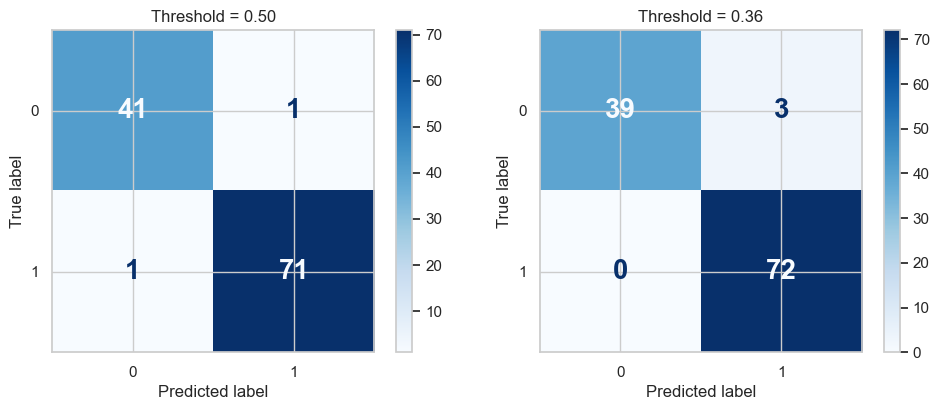

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Threshold 0.5
y_pred_05 = (y_prob >= 0.5).astype(int)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_05, ax=ax[0], cmap='Blues'
)
ax[0].set_title("Threshold = 0.50")

for text in ax[0].texts:
    text.set_fontsize(20)
    text.set_fontweight('bold')

# Threshold 0.36
y_pred_036 = (y_prob >= 0.36).astype(int)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_036, ax=ax[1], cmap='Blues'
)
ax[1].set_title("Threshold = 0.36")

for text in ax[1].texts:
    text.set_fontsize(20)
    text.set_fontweight('bold')

plt.tight_layout()
plt.show()

There is no threshold better than 0.5 that provides a better balance between false positives and false negatives. However, if we prioritize minimizing false negatives due to their higher clinical consequences, we could consider thresholds between 0.36 and 0.34, as these values achieve zero false negatives while keeping the number of false positives relatively low (3).

### 4.3 Storing Model Performance Metrics (for task 7)

The key logistic regression evaluation metrics are saved in the shared `results` dictionary. These values will be reused later for the global model comparison, summary table, and ROC curve in Task 7.

In [40]:
acc = best_lr.score(X_test_scaled_df, y_test)
f1 = f1_score(y_test, y_pred, average='macro')
auc = roc_auc_score(y_test, y_prob)

fpr, tpr, _ = roc_curve(y_test, y_prob)  # for global ROC curve

results['Logistic Regression'] = {
    'accuracy': acc,
    'f1_macro': f1,
    'auc': auc,
    'train_time': train_time,
    'fpr': fpr,  # to plot the global ROC curve
    'tpr': tpr
}

### 4.4 Logistic Regression Coefficients

The coefficients of the Logistic Regression model are analyzed to identify the most influential features in the classification task. Features are ranked according to the absolute magnitude of their coefficients.

In [41]:
# Extract the coefficients 
coefficients = best_lr.coef_[0]

coef_df = pd.DataFrame({
    'feature': X_train_scaled_df.columns,
    'coefficient': coefficients
})

coef_df['abs_coef'] = coef_df['coefficient'].abs() # for sorting by absolute value
coef_df_sorted = coef_df.sort_values(by='abs_coef', ascending=False)

print(coef_df_sorted)

                    feature  coefficient  abs_coef
21            worst texture    -0.665360  0.665360
27     worst concave points    -0.585858  0.585858
20             worst radius    -0.583769  0.583769
10             radius error    -0.538890  0.538890
23               worst area    -0.534519  0.534519
22          worst perimeter    -0.524968  0.524968
28           worst symmetry    -0.499144  0.499144
1              mean texture    -0.492224  0.492224
7       mean concave points    -0.455610  0.455610
13               area error    -0.450377  0.450377
24         worst smoothness    -0.440674  0.440674
0               mean radius    -0.432941  0.432941
26          worst concavity    -0.426605  0.426605
3                 mean area    -0.416424  0.416424
2            mean perimeter    -0.415615  0.415615
12          perimeter error    -0.363555  0.363555
6            mean concavity    -0.344381  0.344381
15        compactness error     0.308135  0.308135
19  fractal dimension error    

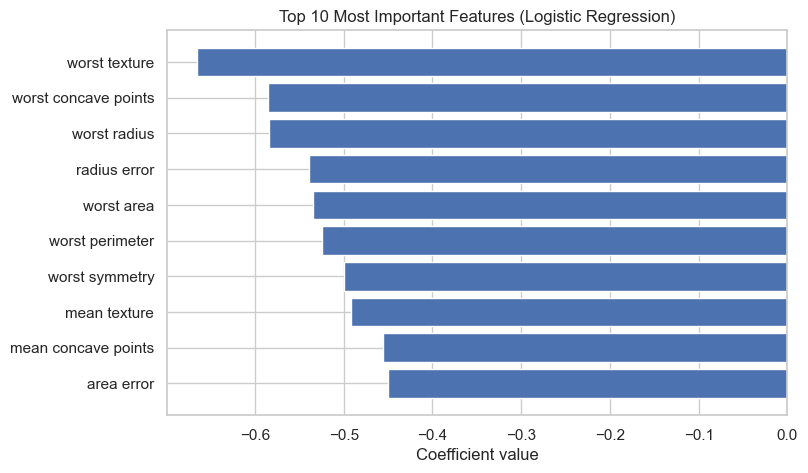

In [42]:
# Select top N features
top_n = 10
top_features = coef_df_sorted.head(top_n)

plt.figure(figsize=(8, 5))
plt.barh(top_features['feature'], top_features['coefficient'])
plt.gca().invert_yaxis() 

plt.xlabel('Coefficient value')
plt.title('Top 10 Most Important Features (Logistic Regression)')
plt.show()

We can observe that the most influential variables are mainly the “worst” features, along with some “error” features. In particular, the top three features are worst texture, worst concave points, and worst radius. This is consistent with expectations, as these variables capture more extreme or severe characteristics of the tumor.

Additionally, most of the coefficients are negative. Since the positive class (1) corresponds to benign cases, this indicates that higher values of these features decrease the probability of a tumor being benign. In other words, larger values in these variables are associated with a higher likelihood of malignancy.

# Task 5: Support Vector Machine ()

# Task 5: Support Vector Machine ()

# Task 6: Neural Network ()

# Task 7: Model comparison & Evaluation (all)

## 7.1 - KNN model

## 7.2 - Logistic Regression model

## 7.3 - SVM model

## 7.6 - Neural Network

## 7.7 - Final analysis and comparison

### ROC Curves

### Summary table

In [17]:
#summary table reporting Accuracy, F1-score (macro), AUC, and approximate training time for every model

### Which model you would deploy in a clinical setting and why?